# Sujan - Experimental Code
The purpose of this document is to experiment with code, without muddying the main project submission python notebook. 

## Clay Exploration

In [1]:

# ── Setup ─────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import yaml
from box import Box
from pathlib import Path

import rasterio
from rasterio.windows import from_bounds
import geopandas as gpd
from shapely.geometry import box as shapely_box
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

from claymodel.module import ClayMAEModule

# Paths — adjust if running from a different working directory
CKPT_PATH    = Path("clay-v1.5.ckpt")
META_PATH    = Path("configs/metadata.yaml")

with open(META_PATH) as f:
    METADATA = Box(yaml.safe_load(f))

print("Setup complete.")


Setup complete.


## Load Clay Model

`ClayMAEModule` wraps `ClayMAE` as `.model`. The actual encoder is at `module.model.encoder`.  
We set `mask_ratio = 0.0` before inference so all 1024 patches are encoded and the CLS token
captures the full chip — then restore it afterwards.


In [2]:

# ── Load Clay v1.5 ────────────────────────────────────────────────────────────
module = ClayMAEModule.load_from_checkpoint(
    str(CKPT_PATH),
    map_location="cpu",
    metadata_path=str(META_PATH),
)
module.eval()
encoder = module.model.encoder

# NAIP sensor config from metadata
NAIP_META   = METADATA["naip"]
# Wavelengths in μm (red, green, blue, nir) — passed directly to encoder
NAIP_WAVES  = torch.tensor(list(NAIP_META.bands.wavelength.values()), dtype=torch.float32)
NAIP_MEANS  = torch.tensor([NAIP_META.bands.mean[b]   for b in NAIP_META.band_order], dtype=torch.float32).view(-1, 1, 1)
NAIP_STDS   = torch.tensor([NAIP_META.bands.std[b]    for b in NAIP_META.band_order], dtype=torch.float32).view(-1, 1, 1)
NAIP_GSD    = torch.tensor(0.6)   # actual 0.6 m resolution; metadata default is 1.0 — override it

print(f"Band order : {list(NAIP_META.band_order)}")
print(f"Wavelengths: {NAIP_WAVES.tolist()} μm")
print(f"Means      : {NAIP_MEANS.squeeze().tolist()}")
print(f"Stds       : {NAIP_STDS.squeeze().tolist()}")


Band order : ['red', 'green', 'blue', 'nir']
Wavelengths: [0.6499999761581421, 0.5600000023841858, 0.47999998927116394, 0.8420000076293945] μm
Means      : [110.16000366210938, 115.41000366210938, 98.1500015258789, 139.0399932861328]
Stds       : [47.22999954223633, 39.81999969482422, 35.43000030517578, 49.86000061035156]


## Helper Functions

### Time / Latlon Encoding
Clay encodes time and position as sin/cos pairs so values are cyclically bounded.
- `time`   → `[sin(2π·week/52), cos(2π·week/52), sin(2π·hour/24), cos(2π·hour/24)]`  → shape `[B, 4]`
- `latlon` → `[sin(lat°), cos(lat°), sin(lon°), cos(lon°)]`                           → shape `[B, 4]`

### Chip Extraction
Each tile in Person 1's grid is a 153.6 m × 153.6 m bounding box (256 px × 0.6 m).
We read a window from the NAIP GeoTIFF that matches each tile bbox, then resize to 256×256
if needed (handles sub-pixel rounding at tile edges).


In [3]:

import math
import torch.nn.functional as F

# ── Time / Latlon encoding ─────────────────────────────────────────────────────

def encode_time(week: int, hour: int = 12) -> torch.Tensor:
    """Return [4] sin/cos encoding for week-of-year and hour-of-day."""
    return torch.tensor([
        math.sin(2 * math.pi * week / 52),
        math.cos(2 * math.pi * week / 52),
        math.sin(2 * math.pi * hour / 24),
        math.cos(2 * math.pi * hour / 24),
    ], dtype=torch.float32)


def encode_latlon(lat: float, lon: float) -> torch.Tensor:
    """Return [4] sin/cos encoding for lat/lon in degrees."""
    return torch.tensor([
        math.sin(math.radians(lat)),
        math.cos(math.radians(lat)),
        math.sin(math.radians(lon)),
        math.cos(math.radians(lon)),
    ], dtype=torch.float32)


# ── Chip extraction from a GeoTIFF ────────────────────────────────────────────

CHIP_PX = 256  # Clay expects 256×256 chips

def extract_chip(src: rasterio.DatasetReader, tile_geom) -> np.ndarray | None:
    """
    Read a 256×256 chip from an open rasterio dataset for a given tile geometry.

    Parameters
    ----------
    src       : open rasterio.DatasetReader (NAIP GeoTIFF, EPSG:32617)
    tile_geom : shapely geometry in the same CRS as src

    Returns
    -------
    chip : float32 ndarray of shape (4, 256, 256), or None if tile is outside raster
    """
    minx, miny, maxx, maxy = tile_geom.bounds
    try:
        window = from_bounds(minx, miny, maxx, maxy, src.transform)
    except Exception:
        return None

    # Skip tiles mostly outside the image
    win_data = src.read(window=window, boundless=True, fill_value=0)  # (4, H, W)

    if win_data.shape[1] == 0 or win_data.shape[2] == 0:
        return None

    # Resize to exactly 256×256 using bilinear interpolation
    chip_t = torch.from_numpy(win_data.astype(np.float32)).unsqueeze(0)  # (1, 4, H, W)
    if chip_t.shape[2] != CHIP_PX or chip_t.shape[3] != CHIP_PX:
        chip_t = F.interpolate(chip_t, size=(CHIP_PX, CHIP_PX), mode="bilinear", align_corners=False)
    return chip_t.squeeze(0).numpy()  # (4, 256, 256)


# ── Normalization ──────────────────────────────────────────────────────────────

def normalize_chip(chip: np.ndarray) -> torch.Tensor:
    """
    Apply per-band z-score normalization using Clay's NAIP training statistics.

    Parameters
    ----------
    chip : float32 ndarray (4, 256, 256) — raw DN values

    Returns
    -------
    torch.Tensor (4, 256, 256)
    """
    t = torch.from_numpy(chip)
    return (t - NAIP_MEANS) / NAIP_STDS


print("Helper functions defined.")


Helper functions defined.


## Clay Inference — Embed All Tiles for One Epoch

`embed_tiles()` iterates over the tile grid, extracts a chip from the NAIP mosaic for each tile,
normalizes it, and runs it through the Clay encoder in batches.

Returns a DataFrame indexed by `tile_id` with 1024 embedding columns.


In [4]:

def embed_tiles(
    naip_path: str | Path,
    tile_grid: gpd.GeoDataFrame,
    week: int,
    hour: int = 12,
    batch_size: int = 16,
    device: str = "cpu",
) -> pd.DataFrame:
    """
    Run Clay inference for every tile in tile_grid against one NAIP GeoTIFF.

    Parameters
    ----------
    naip_path  : path to clipped NAIP mosaic GeoTIFF (EPSG:32617, 4-band RGBN)
    tile_grid  : GeoDataFrame with columns [tile_id, geometry] in EPSG:32617
    week       : ISO week number of the NAIP acquisition (~26 for July)
    hour       : acquisition hour UTC (default 12)
    batch_size : number of chips to encode per forward pass
    device     : 'cpu' or 'cuda'

    Returns
    -------
    DataFrame with tile_id as index and 1024 columns (embed_0 … embed_1023).
    Tiles where the chip is all-zero (outside the mosaic) are dropped.
    """
    enc = encoder.to(device)
    enc.eval()
    original_mask_ratio = enc.mask_ratio
    enc.mask_ratio = 0.0   # disable masking for clean inference

    time_enc   = encode_time(week, hour).to(device)    # [4]
    waves      = NAIP_WAVES.to(device)                 # [4]
    gsd        = NAIP_GSD.to(device)                   # scalar

    records = []   # list of (tile_id, embedding ndarray)

    with rasterio.open(naip_path) as src:
        # Reproject tile centroids to get per-tile lat/lon for position encoding
        tile_centroids = tile_grid.geometry.centroid.to_crs("EPSG:4326")

        # Collect chips in batches
        pending_ids, pending_chips, pending_latlons = [], [], []

        def _flush_batch():
            if not pending_chips:
                return
            chip_tensor   = torch.stack(pending_chips).to(device)        # [B, 4, 256, 256]
            time_batch    = time_enc.unsqueeze(0).expand(len(pending_chips), -1)  # [B, 4]
            latlon_batch  = torch.stack(pending_latlons).to(device)      # [B, 4]

            datacube = {
                "pixels": chip_tensor,
                "time"  : time_batch,
                "latlon": latlon_batch,
                "gsd"   : gsd,
                "waves" : waves,
            }
            with torch.no_grad():
                encoded, _, _, _ = enc(datacube)   # [B, 1025, 1024]
            embeddings = encoded[:, 0, :].cpu().numpy()   # CLS token → [B, 1024]

            for tid, emb in zip(pending_ids, embeddings):
                records.append((tid, emb))

            pending_ids.clear()
            pending_chips.clear()
            pending_latlons.clear()

        for row, centroid in zip(tile_grid.itertuples(), tile_centroids):
            chip = extract_chip(src, row.geometry)
            if chip is None or chip.max() == 0:
                continue   # tile outside mosaic

            norm = normalize_chip(chip)  # [4, 256, 256]

            lat, lon = centroid.y, centroid.x
            latlon_enc = encode_latlon(lat, lon)

            pending_ids.append(row.tile_id)
            pending_chips.append(norm)
            pending_latlons.append(latlon_enc)

            if len(pending_chips) >= batch_size:
                _flush_batch()

        _flush_batch()  # remainder

    enc.mask_ratio = original_mask_ratio

    tile_ids  = [r[0] for r in records]
    emb_array = np.stack([r[1] for r in records])        # (N, 1024)
    cols      = [f"embed_{i}" for i in range(emb_array.shape[1])]
    df        = pd.DataFrame(emb_array, index=tile_ids, columns=cols)
    df.index.name = "tile_id"
    print(f"Embedded {len(df)} tiles ({len(tile_grid) - len(df)} skipped).")
    return df


print("embed_tiles() defined.")


embed_tiles() defined.


## Run Embedding Extraction (both epochs)

**Production run** — waiting on Person 1's handoff. Cell below is commented out.

**Temporary test run** uses a small bbox over southwest Detroit to verify the pipeline end-to-end with real NAIP pulled from Planetary Computer.


In [5]:
#
# # ── Paths — fill in once Person 1 delivers the handoff ────────────────────────
# TILE_GRID_PATH  = Path("../data/detroit_tile_grid.gpkg")   # from Person 1
# NAIP_2018_PATH  = Path("../data/naip_2018_detroit.tif")    # from Person 1
# NAIP_2022_PATH  = Path("../data/naip_2022_detroit.tif")    # from Person 1
#
# # NAIP acquisition weeks (confirm from STAC metadata after Person 1 pulls imagery)
# WEEK_2018 = 26   # ~July 2018
# WEEK_2022 = 26   # ~July 2022
#
# # ── Load tile grid ─────────────────────────────────────────────────────────────
# tile_grid = gpd.read_file(TILE_GRID_PATH).to_crs("EPSG:32617")
# print(f"Tile grid: {len(tile_grid)} tiles")
#
# # ── Embed both epochs ─────────────────────────────────────────────────────────
# emb_2018 = embed_tiles(NAIP_2018_PATH, tile_grid, week=WEEK_2018)
# emb_2022 = embed_tiles(NAIP_2022_PATH, tile_grid, week=WEEK_2022)
#
# # ── Save to disk so we don't have to re-run inference ─────────────────────────
# emb_2018.to_parquet("../data/clay_embeddings_2018.parquet")
# emb_2022.to_parquet("../data/clay_embeddings_2022.parquet")
# print("Embeddings saved.")


In [6]:
# ── TEMPORARY TEST — remove once Person 1 delivers handoff ────────────────────
# Trimmed bbox (~2km x 2km, SW corner of original area) — single 2022 epoch only
import pystac_client
import planetary_computer
import numpy as np
import geopandas as gpd
import rasterio
import rasterio.merge
from rasterio.crs import CRS
from shapely.geometry import box as shapely_box
from pyproj import Transformer
import tempfile, os

# Trimmed from original (-83.127708, 42.318882, -82.996559, 42.406959)
# ~2.4km wide x 2.2km tall → ~210 tiles
TEST_BBOX_WGS84 = (-83.095, 42.350, -83.065, 42.372)

# ── Build tile grid in EPSG:32617 ─────────────────────────────────────────────
TILE_SIZE_M = 153.6
transformer = Transformer.from_crs('EPSG:4326', 'EPSG:32617', always_xy=True)
minx_m, miny_m = transformer.transform(TEST_BBOX_WGS84[0], TEST_BBOX_WGS84[1])
maxx_m, maxy_m = transformer.transform(TEST_BBOX_WGS84[2], TEST_BBOX_WGS84[3])

tiles = [
    {'tile_id': tid, 'geometry': shapely_box(x, y, x + TILE_SIZE_M, y + TILE_SIZE_M)}
    for tid, (x, y) in enumerate(
        (x, y)
        for x in np.arange(minx_m, maxx_m, TILE_SIZE_M)
        for y in np.arange(miny_m, maxy_m, TILE_SIZE_M)
    )
]
test_grid = gpd.GeoDataFrame(tiles, crs='EPSG:32617')
print(f'Test tile grid: {len(test_grid)} tiles')

# ── Pull 2022 NAIP from Planetary Computer ────────────────────────────────────
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)
search = catalog.search(
    collections=['naip'],
    bbox=TEST_BBOX_WGS84,
    datetime='2022-06-01/2022-09-15',
)
items = list(search.items())
print(f'Found {len(items)} NAIP items')
for it in items:
    print(' ', it.id, it.datetime.date())

# ── Mosaic into temp GeoTIFF clipped to bbox ──────────────────────────────────
src_files = [rasterio.open(it.assets['image'].href) for it in items]
mosaic, mosaic_transform = rasterio.merge.merge(
    src_files,
    bounds=(minx_m, miny_m, maxx_m, maxy_m),
    res=0.6,
)
for s in src_files:
    s.close()
print(f'Mosaic shape: {mosaic.shape}')

tmp_naip = tempfile.mktemp(suffix='_naip_test.tif')
with rasterio.open(
    tmp_naip, 'w',
    driver='GTiff',
    height=mosaic.shape[1], width=mosaic.shape[2],
    count=mosaic.shape[0],
    dtype=mosaic.dtype,
    crs=CRS.from_epsg(32617),
    transform=mosaic_transform,
) as dst:
    dst.write(mosaic)

# ── Run Clay inference — 2022 only ────────────────────────────────────────────
emb_2022 = embed_tiles(tmp_naip, test_grid, week=30)  # 2022-07-30 → week 30
print(emb_2022.shape)
print(emb_2022.head())

os.remove(tmp_naip)


Test tile grid: 272 tiles
Found 2 NAIP items
  mi_m_4208348_nw_17_060_20220730 2022-07-30
  mi_m_4208348_ne_17_060_20220730 2022-07-30
Mosaic shape: (4, 3971, 4217)
Embedded 272 tiles (0 skipped).
(272, 1024)
          embed_0   embed_1   embed_2   embed_3   embed_4   embed_5   embed_6  \
tile_id                                                                         
0       -0.103119 -0.019020  0.105158 -0.313529  0.374715 -0.132407  0.799137   
1       -0.113913 -0.063448  0.185343 -0.271352  0.288851 -0.120340  0.604916   
2       -0.263398 -0.076058  0.192190 -0.251409  0.319279 -0.274277  0.683801   
3       -0.240459 -0.103026  0.212072 -0.304279  0.347942 -0.223052  0.752263   
4       -0.215802 -0.046539  0.265711 -0.271028  0.309283 -0.203864  0.657185   

          embed_7   embed_8   embed_9  ...  embed_1014  embed_1015  \
tile_id                                ...                           
0       -0.109157  0.104582 -0.088065  ...    0.058095    0.110641   
1       -0.04

## Change Vectors + K-Means Clustering


In [7]:

# ── Load embeddings (skip if already in memory) ───────────────────────────────
# emb_2018 = pd.read_parquet("../data/clay_embeddings_2018.parquet")
# emb_2022 = pd.read_parquet("../data/clay_embeddings_2022.parquet")

# ── Change vectors: only tiles present in both epochs ─────────────────────────
common = emb_2018.index.intersection(emb_2022.index)
change_vectors = emb_2022.loc[common].values - emb_2018.loc[common].values  # (N, 1024)
print(f"Change vectors: {change_vectors.shape}")

# ── K-Means (k=3: Stable / Improving / Declining) ────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(change_vectors)   # (N,)

results_clay = pd.DataFrame({
    "tile_id": common,
    "clay_cluster": labels,
})
results_clay = results_clay.set_index("tile_id")

print("Cluster counts:")
print(results_clay["clay_cluster"].value_counts())


NameError: name 'emb_2018' is not defined

## Validation Against Ground Truth

Post-hoc label assignment: inspect which cluster captures the most demolition tiles
and which captures the most permit tiles, then assign semantic labels accordingly.


In [ ]:

# ── Join cluster labels onto tile grid + ground truth ─────────────────────────
# tile_grid must have columns: tile_id, has_demolition, has_permit (from Person 1)
gt = tile_grid.set_index("tile_id")[["has_demolition", "has_permit"]].copy()
eval_df = results_clay.join(gt, how="inner")

# ── Per-cluster recall ─────────────────────────────────────────────────────────
for cluster_id in sorted(eval_df["clay_cluster"].unique()):
    sub = eval_df[eval_df["clay_cluster"] == cluster_id]
    n   = len(sub)
    pct_demo   = sub["has_demolition"].mean() * 100
    pct_permit = sub["has_permit"].mean()     * 100
    print(f"Cluster {cluster_id}: n={n:5d}  demolitions={pct_demo:.1f}%  permits={pct_permit:.1f}%")

# ── ARI vs. weak ground truth ─────────────────────────────────────────────────
# Assign weak labels: 1=Declining if has_demolition, 2=Improving if has_permit, 0=Stable
def weak_label(row):
    if row["has_demolition"]:
        return 1
    if row["has_permit"]:
        return 2
    return 0

eval_df["gt_label"] = eval_df.apply(weak_label, axis=1)
ari = adjusted_rand_score(eval_df["gt_label"], eval_df["clay_cluster"])
print(f"\nARI (Clay vs. weak GT): {ari:.4f}")


## Visualizations — Single Epoch Smoke Test

Two plots from `emb_2022` alone:
1. **PCA scatter** — 272 tiles projected to 2D, colored by PC1
2. **Spatial map** — the tile grid colored by PC1, so you can see what Clay is encoding geographically


Variance explained — PC1: 25.0%, PC2: 19.7%


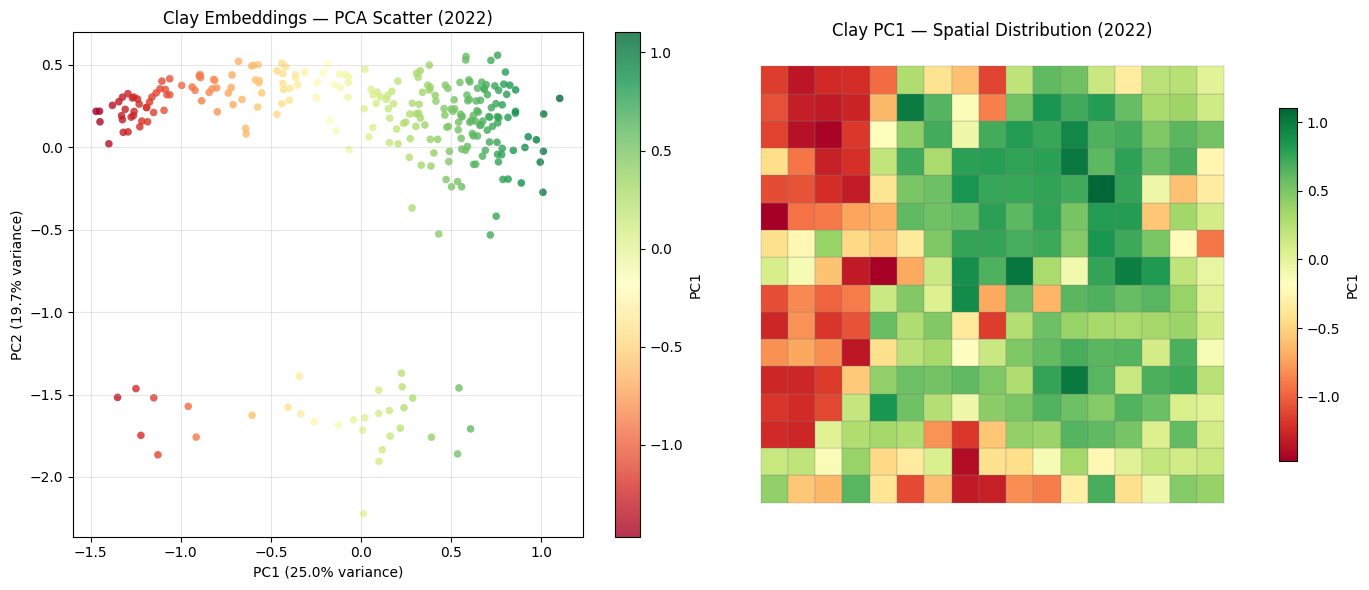

Saved to clay_pca_smoke_test.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA

# ── PCA: 1024 → 2 dims ────────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(emb_2022.values)  # (272, 2)
pc1, pc2 = coords_2d[:, 0], coords_2d[:, 1]

print(f'Variance explained — PC1: {pca.explained_variance_ratio_[0]:.1%}, PC2: {pca.explained_variance_ratio_[1]:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 1: PCA scatter ────────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(pc1, pc2, c=pc1, cmap='RdYlGn', s=30, alpha=0.8, linewidths=0)
plt.colorbar(sc, ax=ax, label='PC1')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Clay Embeddings — PCA Scatter (2022)')
ax.grid(True, alpha=0.3)

# ── Plot 2: Spatial map of PC1 ─────────────────────────────────────────────────
ax = axes[1]
spatial = test_grid.set_index('tile_id').copy()
spatial['pc1'] = pc1

spatial.plot(
    column='pc1',
    cmap='RdYlGn',
    legend=True,
    legend_kwds={'label': 'PC1', 'shrink': 0.7},
    ax=ax,
    linewidth=0.2,
    edgecolor='grey',
)
ax.set_title('Clay PC1 — Spatial Distribution (2022)')
ax.set_axis_off()

plt.tight_layout()
plt.savefig('clay_pca_smoke_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to clay_pca_smoke_test.png')
